# E19 · Learning a graph: Bayesian Gaussian graphical models

| | |
|---|---|
| **Type** | Advanced worked example - read, run, modify |
| **Data** | Sachs et al. (2005): single-cell flow cytometry of 11 phosphorylated proteins and lipids in human T cells, 7466 cells in 9 conditions; the 853 unperturbed cells are used here, scored against the 20-edge consensus signalling network |
| **You will learn** | Marginal vs partial correlation · the precision matrix as a graph (zeros = conditional independence) · a dense precision matrix through `pm.LKJCholeskyCov`, partial correlations as deterministics · edge-inclusion probabilities that depend on a stated relevance threshold · why a horseshoe on the precision matrix itself is a broken model (the positive-definite cone), shown by the sampler · Bayesian neighbourhood selection: node-wise horseshoe regressions with AND / OR symmetrisation · a graphical lasso in 30 lines of NumPy as the frequentist reference · precision-recall against a consensus network, and when shrinkage actually helps · what an undirected graph cannot say |

A cell is a small signalling machine: a stimulus at the membrane activates one protein, which
phosphorylates the next, and so on down a cascade to the nucleus. Sachs and colleagues
measured the phosphorylation of 11 molecules in thousands of individual T cells at once, and
asked whether the *wiring* of the cascade could be read off the data. Their answer (a Bayesian
network) became one of the most cited results in causal discovery, and their data the standard
benchmark for anyone who claims to learn a network.

This notebook tackles the first half of the question: which pairs of molecules are **directly**
connected, whatever the direction? For jointly Gaussian variables that question has an exact
answer in terms of the inverse covariance matrix, and a Bayesian model gives a probability for
every edge. The second half - which way the arrows point - is the subject of **E20**.

In [1]:
import logging
import re
import time
import warnings

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import pytensor.tensor as pt
from matplotlib.lines import Line2D

from pymc_challenges import data

RANDOM_SEED = 2005
rng = np.random.default_rng(RANDOM_SEED)
az.style.use("arviz-variat")
logging.getLogger("pymc").setLevel(logging.WARNING)  # several fits: no banner each time
BLUE, ORANGE, AQUA, GREY, RED = "#2a78d6", "#eb6834", "#1baf7a", "#8a8a86", "#c2185b"
print(f"PyMC {pm.__version__}, ArviZ {az.__version__}")


def draws(idata, name):
    """Posterior draws of one variable as a NumPy array with the samples first."""
    return idata.posterior[name].stack(sample=("chain", "draw")).transpose("sample", ...).to_numpy()


def report(idata, label, var_names):
    div = idata.sample_stats["diverging"].sum("draw").to_numpy()
    with warnings.catch_warnings():             # constant entries (a masked diagonal) give 0/0 in r_hat
        warnings.simplefilter("ignore", RuntimeWarning)
        rhat = max(float(az.rhat(idata, var_names=[v])[v].max()) for v in var_names)
        ess = min(float(az.ess(idata, var_names=[v])[v].min()) for v in var_names)
    print(f"{label}: divergences per chain {div.tolist()}, max r_hat {rhat:.3f}, min bulk ESS {ess:.0f} "
          f"(over {', '.join(var_names)})")

PyMC 6.3.2, ArviZ 1.3.0


## 1 · The data

The registry file is the version curated in the CMU `example-causal-datasets` repository: the
raw fluorescence intensities transformed as $\log(x + 10)$, plus 0/1 indicators of the
experimental condition. The 11 measured molecules are
Raf, Mek, PLC$\gamma$, PIP2, PIP3, Erk, Akt, PKA, PKC, p38 and Jnk.

In [2]:
data.describe("sachs")
sachs = data.load("sachs")
V = list(sachs.columns[:11])
P = len(V)
conditions = sachs.columns[11:]
sachs.groupby(list(conditions)).size().rename("cells").reset_index()

sachs: 7466 cells from 9 conditions, ALL conditions pooled. Columns 1-11 are log(x + 10) of the raw intensities (raf mek plc pip2 pip3 erk akt pka pkc p38 jnk); columns 12-20 are 0/1 condition indicators (cd3_cd28 stimulation, icam2, and the reagents aktinhib g0076 psitect u0126 ly pma b2camp). The 853 cells with cd3_cd28 = 1 and all reagents 0 are the purely observational set.
  source: Sachs et al. (2005, Science 308:523), single-cell flow cytometry of 11 phosphoproteins/lipids in human T cells, via the CMU example-causal-datasets repository.
  url:    https://raw.githubusercontent.com/cmu-phil/example-causal-datasets/main/real/sachs/data/sachs.2005.continuous.discrete.experimental.mixed.maximum.2.txt


,cd3_cd28,icam2,aktinhib,g0076,psitect,u0126,ly,pma,b2camp,cells
0,0,0,0,0,0,0,0,0,1,707
1,0,0,0,0,0,0,0,1,0,913
2,1,0,0,0,0,0,0,0,0,853
3,1,0,0,0,0,0,1,0,0,848
4,1,0,0,0,0,1,0,0,0,799
5,1,0,0,0,1,0,0,0,0,810
6,1,0,0,1,0,0,0,0,0,723
7,1,0,1,0,0,0,0,0,0,911
8,1,1,0,0,0,0,0,0,0,902


Every cell was stimulated through its receptor (`cd3_cd28`) or by one of two other routes
(`b2camp`, `pma`), and in most conditions an extra reagent **inhibits or activates one
specific molecule** (`u0126` inhibits Mek, `aktinhib` Akt, `psitect` PIP2, `ly` the PI3K
route to Akt, `g0076` PKC). Those are interventions: each one changes the system, and pooling
them would mix nine different joint distributions (section 8 shows what that does). Here we
use only the **853 cells with the plain CD3/CD28 stimulus** - the observational slice, the
same one used by the classical `bnlearn` version of the data.

The consensus network is the one Sachs et al. assembled from the literature (their Fig. 2/3):
20 directed edges. For an undirected graph only the **skeleton** matters: 20 of the 55 possible
pairs are connected.

In [3]:
data.describe("sachs_consensus")
consensus_edges = re.findall(r"\d+\. (\w+) --> (\w+)", data.path("sachs_consensus").read_text())
TRUE = np.zeros((P, P), bool)
for a, b in consensus_edges:
    TRUE[V.index(a), V.index(b)] = TRUE[V.index(b), V.index(a)] = True
IU = np.triu_indices(P, 1)                      # the 55 pairs (j < k)
PAIRS = [f"{V[j]}-{V[k]}" for j, k in zip(*IU)]
truth = TRUE[IU]
print(f"{len(consensus_edges)} directed consensus edges -> {truth.sum()} undirected pairs out of {len(truth)}")
print(", ".join(f"{a}->{b}" for a, b in consensus_edges))

obs = sachs[(sachs.cd3_cd28 == 1) & (sachs[conditions].sum(axis=1) == 1)]
X = obs[V].to_numpy()
Z = (X - X.mean(0)) / X.std(0)                  # standardised: every edge weight on one scale
N = len(Z)
print(f"observational cells: {N}")

sachs_consensus: 20 directed edges between the 11 `sachs` variables, lines like '1. erk --> akt'. Not a table: parse data.path().
  source: Consensus signalling network of Sachs et al. (2005, Fig. 2/3), as curated in CMU example-causal-datasets.
  url:    https://raw.githubusercontent.com/cmu-phil/example-causal-datasets/main/real/sachs/ground.truth/sachs.2005.ground.truth.graph.txt
20 directed consensus edges -> 20 undirected pairs out of 55
erk->akt, mek->erk, pip2->pkc, pip3->akt, pip3->pip2, pip3->plc, pka->akt, pka->erk, pka->jnk, pka->mek, pka->p38, pka->raf, pkc->jnk, pkc->mek, pkc->p38, pkc->pka, pkc->raf, plc->pip2, plc->pkc, raf->mek
observational cells: 853


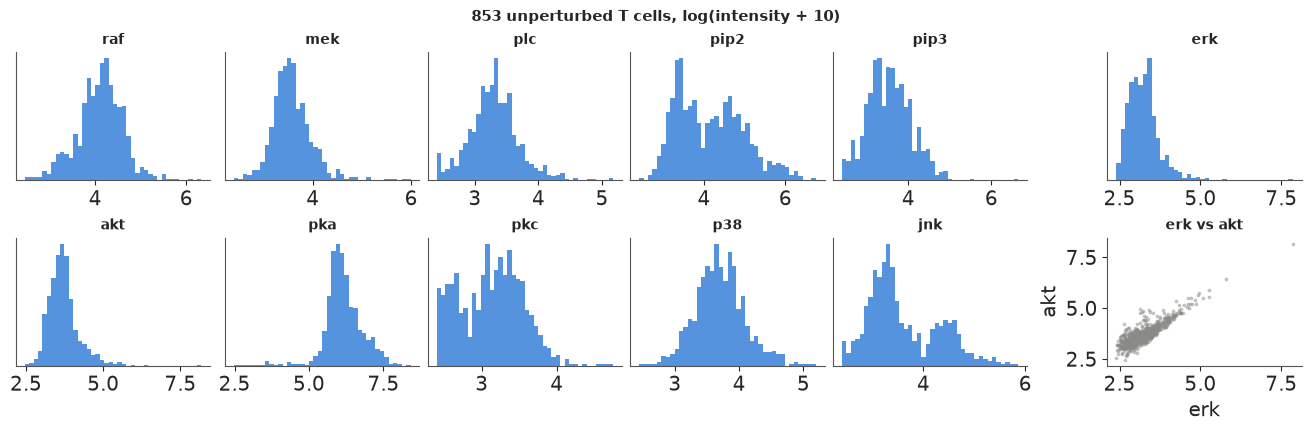

In [4]:
fig, axes = plt.subplots(2, 6, figsize=(13, 4.2))
for ax, j in zip(axes.flat, range(P)):
    ax.hist(X[:, j], bins=40, color=BLUE, alpha=0.8)
    ax.set_title(V[j], fontsize=10)
    ax.set_yticks([])
ax = axes.flat[-1]
ax.scatter(X[:, V.index("erk")], X[:, V.index("akt")], s=3, alpha=0.4, color=GREY)
ax.set(xlabel="erk", ylabel="akt")
ax.set_title("erk vs akt", fontsize=10)
fig.suptitle("853 unperturbed T cells, log(intensity + 10)", fontsize=11);

Not one of these looks like a textbook Gaussian. Erk and Akt have long right tails; Jnk and
PIP2 look like two populations of cells; PLC, PIP3 and PKC pile up at the left edge, where
$\log(x + 10)$ puts every reading near zero. A Gaussian graphical model will see only the
*linear* part of the dependence - keep that in mind, we check it in section 3. The one scatter
shows the strongest pair of the data set: Erk and Akt move almost in lockstep.

## 2 · Marginal and partial correlation

Two molecules can be correlated because one phosphorylates the other, or because both sit
downstream of a third. A graph of **direct** connections wants the second kind removed:
the correlation of $X_j$ and $X_k$ *after accounting for all the other variables*, the
**partial correlation**.

For a multivariate normal vector with covariance $\Sigma$, everything we need is in the
**precision matrix** $\Omega = \Sigma^{-1}$:

$$
\rho_{jk \cdot \text{rest}} = -\frac{\Omega_{jk}}{\sqrt{\Omega_{jj}\Omega_{kk}}}, \qquad
\Omega_{jk} = 0 \iff X_j \perp X_k \mid X_{\text{rest}} .
$$

So the zero pattern of $\Omega$ *is* an undirected graph: an edge wherever $\Omega_{jk} \ne 0$.
That is the **Gaussian graphical model** (GGM). The same numbers appear in regression:
regressing $X_j$ on all the others gives coefficients $\beta_{jk} = -\Omega_{jk}/\Omega_{jj}$,
so an edge is also "$X_k$ has a non-zero coefficient when predicting $X_j$" - an identity that
section 5 will exploit.

First, the plug-in (maximum-likelihood) versions of both matrices.

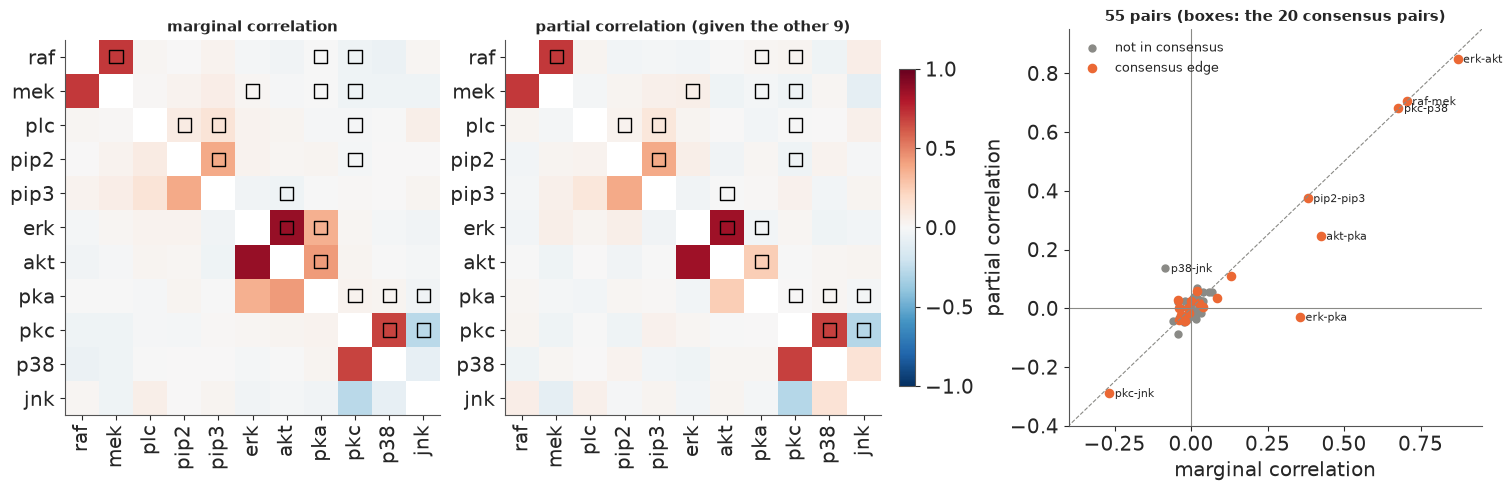

In [5]:
R = np.corrcoef(Z.T)
Omega_hat = np.linalg.inv(np.cov(Z.T))
PC = -Omega_hat / np.sqrt(np.outer(np.diag(Omega_hat), np.diag(Omega_hat)))
np.fill_diagonal(PC, 1.0)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.8), gridspec_kw={"width_ratios": [1, 1, 1.1]})
for ax, M, title in zip(axes[:2], [R, PC], ["marginal correlation", "partial correlation (given the other 9)"]):
    im = ax.imshow(np.where(np.eye(P, dtype=bool), np.nan, M), cmap="RdBu_r", vmin=-1, vmax=1)
    ax.set_xticks(range(P), V, rotation=90)
    ax.set_yticks(range(P), V)
    jj, kk = np.nonzero(np.triu(TRUE))
    ax.scatter(kk, jj, marker="s", s=90, facecolor="none", edgecolor="k", lw=1)
    ax.set_title(title, fontsize=11)
fig.colorbar(im, ax=axes[1], shrink=0.8)
ax = axes[2]
ax.axhline(0, color=GREY, lw=0.8)
ax.axvline(0, color=GREY, lw=0.8)
ax.scatter(R[IU][~truth], PC[IU][~truth], color=GREY, s=25, label="not in consensus")
ax.scatter(R[IU][truth], PC[IU][truth], color=ORANGE, s=35, label="consensus edge")
for j, k in zip(*IU):
    if abs(PC[j, k]) > 0.2 or abs(R[j, k] - PC[j, k]) > 0.15:
        ax.annotate(f"{V[j]}-{V[k]}", (R[j, k], PC[j, k]), fontsize=8, xytext=(4, -3), textcoords="offset points")
ax.plot([-1, 1], [-1, 1], color=GREY, ls="--", lw=0.8)
ax.set(xlabel="marginal correlation", ylabel="partial correlation", xlim=(-0.4, 0.95), ylim=(-0.4, 0.95))
ax.legend(loc="upper left", fontsize=9)
ax.set_title("55 pairs (boxes: the 20 consensus pairs)", fontsize=11);

Most pairs sit near zero on both scales, and the three strongest (Erk-Akt, Raf-Mek, PKC-p38)
barely change when the other nine variables are accounted for: direct links. The interesting
pairs are the ones that move:

- **Erk-PKA**: marginal correlation 0.36, partial correlation -0.03. PKA and Erk are correlated,
  but that is all carried by Akt (PKA-Akt 0.25, Akt-Erk 0.85); given Akt they are unrelated.
  The consensus network *has* a PKA $\to$ Erk edge - in unperturbed cells it is invisible.
- **p38-Jnk**: marginal -0.08, partial +0.14. Both depend on PKC, in opposite directions
  (PKC-p38 +0.68, PKC-Jnk -0.29), which masks a positive association that only appears once
  PKC is held fixed. The consensus has no p38-Jnk edge.

About eight pairs stand clearly away from zero; the consensus has 20. Several consensus pairs
(PLC-PIP2, PIP2-PKC, Mek-PKC, ...) have partial correlations indistinguishable from zero in these cells.

How sure are we about each of these numbers, and which of them are "really" zero? That is a
job for a posterior.

## 3 · Model A: a dense precision matrix

The direct route: put a prior on the covariance, get the precision matrix and the partial
correlations as deterministic functions of it. PyMC's `LKJCholeskyCov` puts an LKJ prior on the
correlation matrix and a separate prior on the standard deviations, and returns the Cholesky
factor $L$ with $\Sigma = LL^\top$. Then $\Omega = L^{-\top}L^{-1}$ needs only a triangular
solve - no general matrix inverse, and positive-definite by construction.

$$
z_i \sim \text{MvNormal}(\mu, LL^\top), \quad L \sim \text{LKJCholeskyCov}(\eta = 2,\ \text{sd} \sim \text{Exponential}(1)),
\quad \mu_j \sim \text{Normal}(0, 1).
$$

The data are standardised, so the standard deviations are near 1 and the prior on them hardly
matters. $\eta = 2$ gently favours weaker correlations; what it implies for the *partial*
correlations is not obvious, so we look at the prior predictive first.

In [6]:
def dense_model(Zdata):
    coords = {"cell": np.arange(len(Zdata)), "var": V, "var_": V}
    with pm.Model(coords=coords) as model:
        chol, _, _ = pm.LKJCholeskyCov("chol", n=P, eta=2.0, sd_dist=pm.Exponential.dist(1.0), compute_corr=True)
        mu = pm.Normal("mu", 0.0, 1.0, dims="var")
        pm.MvNormal("z", mu, chol=chol, observed=Zdata, dims=("cell", "var"))
        L_inv = pt.linalg.solve_triangular(chol, pt.eye(P), lower=True)
        Omega = L_inv.T @ L_inv
        scale = pt.sqrt(pt.diag(Omega))
        pm.Deterministic("pcor", -Omega / pt.outer(scale, scale) + 2 * pt.eye(P), dims=("var", "var_"))
    return model


m_dense = dense_model(Z)
with m_dense:
    prior = pm.sample_prior_predictive(1000, var_names=["pcor"], random_seed=RANDOM_SEED)
prior_pc = prior.prior["pcor"].stack(sample=("chain", "draw")).transpose("sample", ...).to_numpy()[:, IU[0], IU[1]]
print(f"prior partial correlations: sd {prior_pc.std():.2f}, P(|rho| > 0.1) = {(np.abs(prior_pc) > 0.1).mean():.2f}")

prior partial correlations: sd 0.40, P(|rho| > 0.1) = 0.83


A mild prior on the correlations is **not** a mild prior on the graph. The partial correlations
implied by LKJ($\eta = 2$) in 11 dimensions have a prior sd of 0.40, and every one of the 55 pairs
has an 83% prior probability of being an edge by the $|\rho| > 0.1$ definition used below. In
graph terms this is a prior for a *dense* network. With 853 cells the likelihood will not care;
section 4 shows when it does.

In [7]:
t0 = time.time()
with m_dense:
    idata_dense = pm.sample(random_seed=RANDOM_SEED, progressbar=False)
print(f"dense model, {N} cells: {time.time() - t0:.0f} s, warm-up {idata_dense.posterior.attrs.get('tuning_steps')} steps")
report(idata_dense, "dense", ["chol", "mu"])

dense model, 853 cells: 7 s, warm-up 400 steps
dense: divergences per chain [0, 0, 0, 0], max r_hat 1.004, min bulk ESS 2732 (over chol, mu)


No divergences, r_hat at most 1.004, bulk ESS above 2700 for every element of the Cholesky
factor: a well-behaved 77-parameter posterior, sampled in seconds.

**Posterior predictive check.** The model says every variable is Gaussian and every
dependence linear. The histograms above already doubt that; the check makes it concrete.

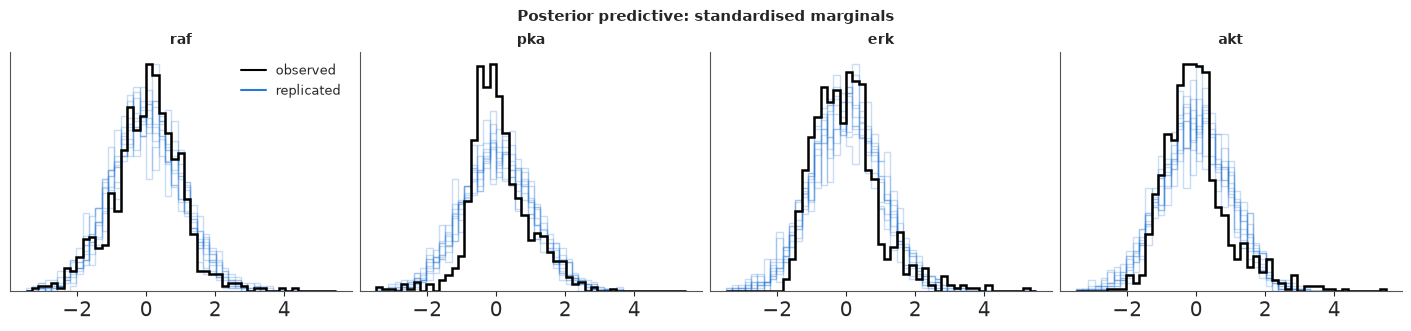

In [8]:
with m_dense:
    ppc = pm.sample_posterior_predictive(idata_dense.isel(draw=slice(None, None, 50)), random_seed=RANDOM_SEED,
                                         progressbar=False)
z_rep = ppc.posterior_predictive["z"].stack(sample=("chain", "draw")).transpose("sample", ...).to_numpy()
fig, axes = plt.subplots(1, 4, figsize=(14, 3.2))
for ax, name in zip(axes, ["raf", "pka", "erk", "akt"]):
    j = V.index(name)
    bins = np.linspace(-3.5, 5.5, 50)
    for s in range(0, len(z_rep), 8):
        ax.hist(z_rep[s, :, j], bins=bins, histtype="step", color=BLUE, alpha=0.25, density=True)
    ax.hist(Z[:, j], bins=bins, histtype="step", color="k", lw=1.8, density=True)
    ax.set_title(name, fontsize=10)
    ax.set_yticks([])
axes[0].legend([Line2D([], [], color="k"), Line2D([], [], color=BLUE)], ["observed", "replicated"], fontsize=9)
fig.suptitle("Posterior predictive: standardised marginals", fontsize=11);
del ppc, z_rep

Raf is reproduced well. PKA, Erk and Akt are not: the observed marginals are more peaked than
any replicate, with a longer right tail. The Gaussian is a summary of the linear dependence,
not a model of these cells, and "zero partial correlation = conditional independence" is
only guaranteed for Gaussians - a nonlinear link could hide behind a small $\rho$. The graph
below is a graph of *linear* conditional dependence. (Try it yourself 1 swaps in a heavy-tailed
likelihood.)

### Partial correlations and edge probabilities

The posterior of $\rho_{jk}$ is continuous, so $P(\rho_{jk} = 0) = 0$ and "the probability of
an edge" needs a definition. The honest one is a **relevance threshold**: an edge is present if
$|\rho_{jk}| > \delta$, and its probability is $P(|\rho_{jk}| > \delta \mid \text{data})$. We use
$\delta = 0.1$ - a partial correlation that explains 1% of the remaining variance. That is a
choice, not a law; with 853 cells the posterior sd of each $\rho_{jk}$ is only about 0.03, so
almost everything above 0.1 is "certain" and the threshold, not the data, decides which of the
weak edges count.

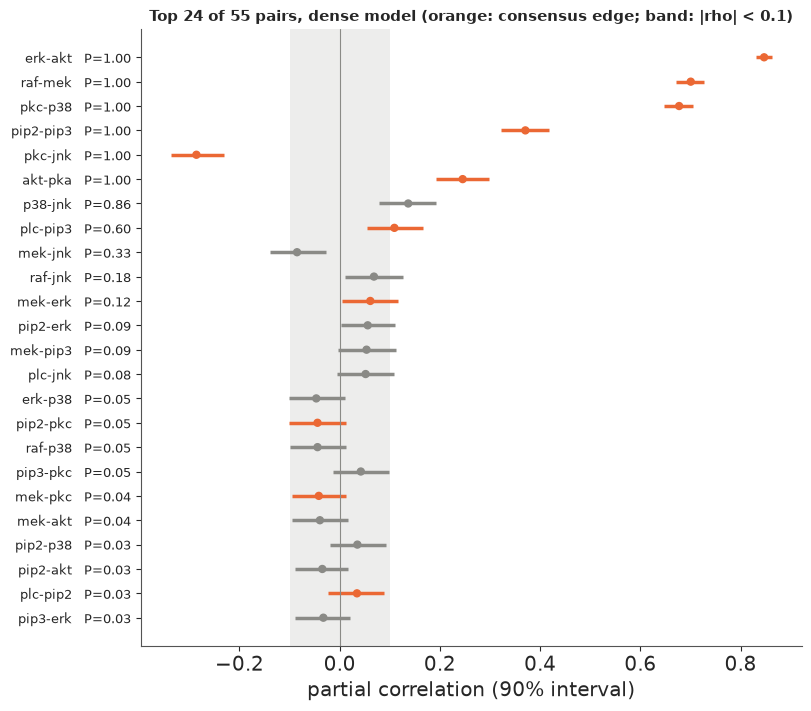

In [9]:
DELTA = 0.1
pc_dense = draws(idata_dense, "pcor")[:, IU[0], IU[1]]
prob_dense = (np.abs(pc_dense) > DELTA).mean(0)
order = np.argsort(np.abs(np.median(pc_dense, 0)))[::-1][:24][::-1]
lo, med, hi = np.quantile(pc_dense[:, order], [0.05, 0.5, 0.95], axis=0)
fig, ax = plt.subplots(figsize=(8, 7))
colors = np.where(truth[order], ORANGE, GREY)
ax.hlines(range(len(order)), lo, hi, color=colors, lw=2.5)
ax.scatter(med, range(len(order)), color=colors, s=25, zorder=3)
ax.axvspan(-DELTA, DELTA, color=GREY, alpha=0.15, lw=0)
ax.axvline(0, color=GREY, lw=0.8)
ax.set_yticks(range(len(order)), [f"{PAIRS[i]}   P={prob_dense[i]:.2f}" for i in order], fontsize=9)
ax.set(xlabel="partial correlation (90% interval)")
ax.set_title("Top 24 of 55 pairs, dense model (orange: consensus edge; band: |rho| < 0.1)", fontsize=11);

Six pairs have $P = 1.00$, and all six are consensus edges: Erk-Akt, Raf-Mek, PKC-p38,
PIP2-PIP3, PKC-Jnk and Akt-PKA. Then come p38-Jnk (0.86, not in the consensus) and PLC-PIP3
(0.60, in the consensus), and after that nothing with a probability above 0.33. The Mek-Erk
pair - the textbook kinase step of the MAPK cascade - has a 90% interval that excludes zero
but lies inside the $\pm 0.1$ band: a real but tiny partial correlation, $P = 0.12$. These
posteriors are narrow (sd about 0.03), so the missing consensus edges are not a matter of
noise: in unperturbed cells, about 12 of the 20 literature edges simply do not show up as
linear partial correlations.

## 4 · When does shrinkage matter? A small experiment of 100 cells

With 853 cells and 55 unknown partial correlations the likelihood does all the work, and the
prior hardly matters. The case for a *sparse* prior - one that believes most pairs are not
connected - is the small experiment: tens of samples, dozens of candidate edges. To see it we
draw 100 random cells from the 853 and fit the dense model again. The full-data posterior is
our yardstick for what "the right answer" looks like on these data.

In [10]:
N_SMALL = 100
sub = rng.choice(N, N_SMALL, replace=False)
Zs = (X[sub] - X[sub].mean(0)) / X[sub].std(0)
with dense_model(Zs):
    idata_dense_s = pm.sample(random_seed=RANDOM_SEED, progressbar=False)
report(idata_dense_s, "dense, 100 cells", ["chol", "mu"])
pc_dense_s = draws(idata_dense_s, "pcor")[:, IU[0], IU[1]]
prob_dense_s = (np.abs(pc_dense_s) > DELTA).mean(0)
del idata_dense_s
print(f"posterior sd of a partial correlation: {pc_dense.std(0).mean():.3f} with {N} cells, "
      f"{pc_dense_s.std(0).mean():.3f} with {N_SMALL}")
print(f"pairs with 0.2 < P(|rho| > 0.1) < 0.8 (undecided): {((prob_dense > 0.2) & (prob_dense < 0.8)).sum()} "
      f"with {N} cells, {((prob_dense_s > 0.2) & (prob_dense_s < 0.8)).sum()} with {N_SMALL}")

dense, 100 cells: divergences per chain [0, 0, 0, 0], max r_hat 1.004, min bulk ESS 2322 (over chol, mu)
posterior sd of a partial correlation: 0.033 with 853 cells, 0.094 with 100
pairs with 0.2 < P(|rho| > 0.1) < 0.8 (undecided): 2 with 853 cells, 43 with 100


With 100 cells the posterior sd of each partial correlation triples (0.033 to 0.094), and the
number of undecided pairs goes from 2 to 43 out of 55. The dense prior - 83% prior probability
on every edge - is no longer swamped by the data, and the posterior says "maybe" to almost
everything. A prior that expects *few* edges should help here.

### The naive sparse model, and why it is broken

The obvious move is to copy the horseshoe from sparse regression onto the off-diagonal of the
precision matrix:

$$
\Omega_{jk} = z_{jk}\,\lambda_{jk}\,\tau, \quad z_{jk} \sim \text{Normal}(0,1), \ \lambda_{jk} \sim \text{HalfCauchy}(1),
\ \tau \sim \text{HalfCauchy}(0.1), \qquad \Omega_{jj} \sim \text{LogNormal}(0, 1).
$$

The problem is that $\Omega$ must be **positive definite**, and most matrices built this way are
not. The likelihood is undefined outside that cone, so the model we would actually be fitting is
"horseshoe *truncated* to positive-definite matrices", whose normalising constant depends on
$\tau$ and every $\lambda_{jk}$ and is silently dropped. How much of the prior is lost?

In [11]:
for tau in [0.01, 0.05, 0.1, 0.3]:
    n_sim = 4000
    off = tau * np.abs(rng.standard_cauchy((n_sim, len(PAIRS)))) * rng.standard_normal((n_sim, len(PAIRS)))
    Om = np.zeros((n_sim, P, P))
    Om[:, IU[0], IU[1]] = off
    Om = Om + Om.transpose(0, 2, 1)
    Om[:, np.arange(P), np.arange(P)] = np.exp(rng.standard_normal((n_sim, P)))
    print(f"tau = {tau:<5}: {100 * (np.linalg.eigvalsh(Om)[:, 0] > 0).mean():5.1f}% of prior draws are positive definite")
del Om, off

tau = 0.01 :  68.0% of prior draws are positive definite
tau = 0.05 :  12.5% of prior draws are positive definite
tau = 0.1  :   1.4% of prior draws are positive definite
tau = 0.3  :   0.0% of prior draws are positive definite


At $\tau = 0.1$, the median of its prior, only 1.4% of the matrices the prior describes are
valid precision matrices; at 0.3 none are. Worse, the lost fraction depends on $\tau$ (68% kept at
0.01, 0% at 0.3), so the truncation acts as an extra, unwritten prior pushing $\tau$ towards
zero. The posterior we would compute is not the posterior of the model we wrote down.

The sampler finds out the hard way. We fit the naive model to the 100 cells.

In [12]:
def naive_model(Zdata):
    coords = {"cell": np.arange(len(Zdata)), "var": V, "pair": PAIRS}
    with pm.Model(coords=coords) as model:
        tau = pm.HalfCauchy("tau", 0.1)
        lam = pm.HalfCauchy("lam", 1.0, dims="pair")
        z = pm.Normal("z_raw", 0.0, 1.0, dims="pair")
        off = pm.Deterministic("off", z * lam * tau, dims="pair")
        diag = pm.LogNormal("diag", 0.0, 1.0, dims="var")
        U = pt.zeros((P, P))[IU].set(off)
        pm.MvNormal("z", 0.0, tau=pt.diag(diag) + U + U.T, observed=Zdata, dims=("cell", "var"))
    return model


m_naive = naive_model(Zs)
point = m_naive.initial_point()
point["z_raw"] = np.full(len(PAIRS), 3.0)       # a legal value of every parameter ...
point["tau_log__"] = np.array(np.log(1.0))
print("log-density at a non-positive-definite Omega:", m_naive.compile_logp()(point))
with m_naive:
    idata_naive = pm.sample(target_accept=0.95, random_seed=RANDOM_SEED, progressbar=False)
report(idata_naive, "naive horseshoe on Omega", ["tau", "off"])
msgs = idata_naive.sample_stats["divergence_message"].to_numpy()[idata_naive.sample_stats["diverging"].to_numpy()]
print(pd.Series([str(m).split(":")[0] for m in msgs]).value_counts().to_string())

log-density at a non-positive-definite Omega: -inf


naive horseshoe on Omega: divergences per chain [83, 38, 54, 106], max r_hat 1.024, min bulk ESS 121 (over tau, off)
Logp function returned error code       241
Divergence due to large energy error     40


A non-positive-definite $\Omega$ has log-density $-\infty$: a wall in the middle of the
parameter space, not a smooth funnel. NUTS runs into it constantly: 281 divergences in 4000
draws, 241 of which nutpie reports as "Logp function returned error code" - trajectories
that stepped out of the cone - and the global scale mixes poorly (r_hat 1.024, bulk ESS 121).
These are not the usual horseshoe-funnel divergences that a higher `target_accept` cures;
the model is broken by construction.

There are principled fixes - the *graphical horseshoe* of Li, Craig & Bhadra (2019) uses a
Gibbs sampler that updates one column at a time and never leaves the cone, and G-Wishart priors
handle exact zeros with reversible jumps - but none of them is a NUTS model. The fix that *is*
comes from the regression identity of section 2.

## 5 · Model B: Bayesian neighbourhood selection

Meinshausen & Bühlmann (2006) noticed that the edges at node $j$ are exactly the non-zero
coefficients when $X_j$ is regressed on all other variables, $\beta_{jk} = -\Omega_{jk}/\Omega_{jj}$.
So we can learn the graph with **11 sparse regressions**, one per node, and never touch a
positive-definite constraint:

$$
z_{ij} \sim \text{Normal}\Big(\sum_{k \ne j} \beta_{jk} z_{ik},\ \sigma_j\Big), \qquad
\beta_{jk} \sim \text{regularised horseshoe}(\tau_j, \lambda_{jk}, c).
$$

Each node gets its own global scale $\tau_j$, set in the Piironen & Vehtari (2017) way from a
guess of $p_0 = 2$ neighbours out of 10: $\tau_0 = \frac{p_0}{10 - p_0}\frac{\sigma_j}{\sqrt n}$
times a HalfCauchy(1). The slab $c^2 \sim \text{InvGamma}(2, 2)$ keeps the large coefficients
from being unregularised. All 11 regressions share one PyMC model (the $11 \times 11$ matrix $B$
with its diagonal masked out), so one call samples them all.

The price: the 11 regressions are fitted **separately**, so $\beta_{jk}$ and $\beta_{kj}$ need
not agree about the edge $j - k$. Two symmetrisation rules are standard:
**AND** (both regressions keep the edge) and **OR** (either does). With a posterior these are
just events computed draw by draw:
$P_{\text{AND}} = P(|\beta_{jk}| > \delta \text{ and } |\beta_{kj}| > \delta)$,
$P_{\text{OR}} = P(|\beta_{jk}| > \delta \text{ or } |\beta_{kj}| > \delta)$.
(In an exact Gaussian $\beta_{jk}\beta_{kj} = \rho_{jk}^2$, so $|\beta| > 0.1$ is on the same scale
as the threshold used for the dense model.)

In [13]:
def ns_model(Zdata, p0=2.0):
    n = len(Zdata)
    tau0 = p0 / (P - 1 - p0) / np.sqrt(n)
    mask = 1.0 - np.eye(P)
    coords = {"cell": np.arange(n), "target": V, "predictor": V}
    with pm.Model(coords=coords) as model:
        sigma = pm.HalfNormal("sigma", 1.0, dims="target")
        tau = pm.HalfCauchy("tau", 1.0, dims="target")
        lam = pm.HalfCauchy("lam", 1.0, dims=("target", "predictor"))
        c2 = pm.InverseGamma("c2", 2.0, 2.0)
        t = (tau0 * tau * sigma)[:, None]
        lam_tilde = pt.sqrt(c2 * lam**2 / (c2 + t**2 * lam**2))
        z = pm.Normal("z_raw", 0.0, 1.0, dims=("target", "predictor"))
        B = pm.Deterministic("B", z * lam_tilde * t * mask, dims=("target", "predictor"))
        pm.Normal("z", pt.as_tensor(Zdata) @ B.T, sigma[None, :], observed=Zdata, dims=("cell", "target"))
    return model


def ns_edge_probs(B):
    """AND / OR edge probabilities and a symmetric partial-correlation estimate from draws of B."""
    b_jk, b_kj = np.abs(B[:, IU[0], IU[1]]), np.abs(B[:, IU[1], IU[0]])
    p_and = ((b_jk > DELTA) & (b_kj > DELTA)).mean(0)
    p_or = ((b_jk > DELTA) | (b_kj > DELTA)).mean(0)
    prod = B[:, IU[0], IU[1]] * B[:, IU[1], IU[0]]
    rho = np.sign(B[:, IU[0], IU[1]]) * np.sqrt(np.clip(prod, 0, None))  # 0 when the signs disagree
    return p_and, p_or, rho


fits_ns = {}
for label, Zdata in [("100 cells", Zs), (f"{N} cells", Z)]:
    t0 = time.time()
    with ns_model(Zdata):
        idata_ns = pm.sample(target_accept=0.99, random_seed=RANDOM_SEED, progressbar=False)
    print(f"neighbourhood selection, {label}: {time.time() - t0:.0f} s")
    report(idata_ns, f"  {label}", ["tau", "sigma", "c2", "B"])
    fits_ns[label] = ns_edge_probs(draws(idata_ns, "B"))
    p_and = fits_ns[label][0]
    print(f"  undecided pairs (0.2 < P_AND < 0.8): {((p_and > 0.2) & (p_and < 0.8)).sum()}; "
          f"edges with P_AND > 0.5: {(p_and > 0.5).sum()}")
    if label == "100 cells":
        B_small = draws(idata_ns, "B")
    del idata_ns
beta_hat = -Omega_hat / np.diag(Omega_hat)[:, None]      # plug-in regression coefficients, all 853 cells
a, k = V.index("akt"), V.index("pka")
print(f"plug-in: akt on pka {beta_hat[a, k]:.2f}, pka on akt {beta_hat[k, a]:.2f}; "
      f"Omega_jj: akt {Omega_hat[a, a]:.1f}, pka {Omega_hat[k, k]:.1f}")

neighbourhood selection, 100 cells: 3 s
  100 cells: divergences per chain [0, 0, 0, 0], max r_hat 1.008, min bulk ESS 358 (over tau, sigma, c2, B)
  undecided pairs (0.2 < P_AND < 0.8): 0; edges with P_AND > 0.5: 4


neighbourhood selection, 853 cells: 40 s
  853 cells: divergences per chain [0, 1, 0, 1], max r_hat 1.012, min bulk ESS 918 (over tau, sigma, c2, B)
  undecided pairs (0.2 < P_AND < 0.8): 1; edges with P_AND > 0.5: 6
plug-in: akt on pka 0.13, pka on akt 0.47; Omega_jj: akt 4.4, pka 1.2


Clean fits: no divergences with 100 cells and 2 in 4000 draws with 853 (r_hat at most 1.012,
bulk ESS above 350). Horseshoes make funnels of their own, so we sample at
`target_accept=0.99`; at 0.95 the 853-cell fit had a few dozen divergences in trial runs.
The key difference from the dense model: with 100 cells there are **no** undecided pairs
(four edges above 0.5, everything else near 0), and with 853 cells one.

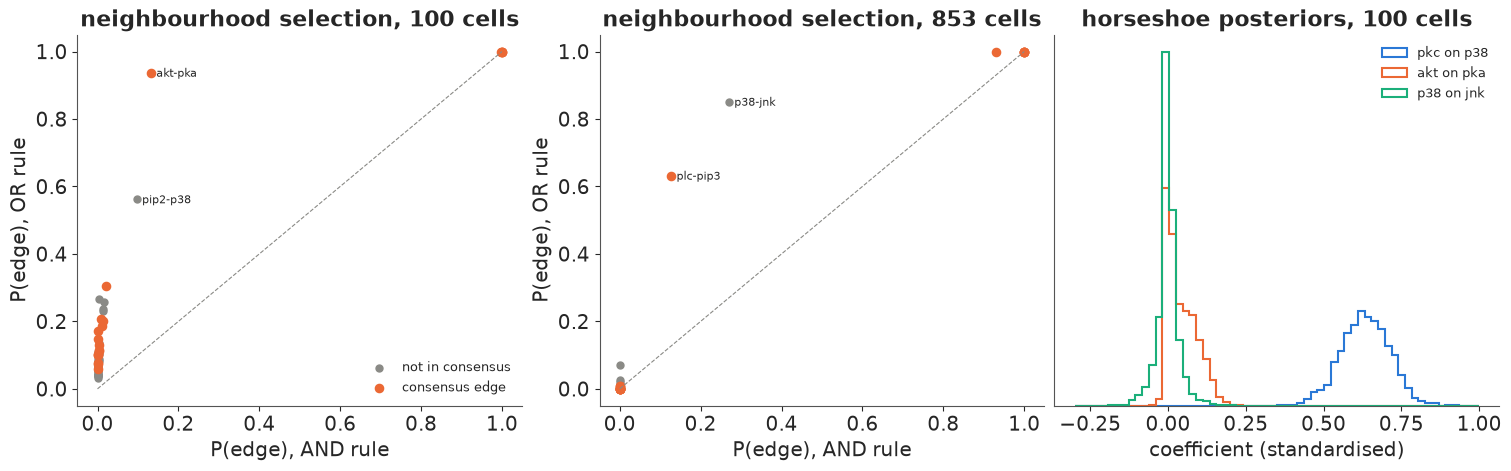

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))
for ax, label in zip(axes[:2], fits_ns):
    p_and, p_or, _ = fits_ns[label]
    ax.scatter(p_and[~truth], p_or[~truth], color=GREY, s=25, label="not in consensus")
    ax.scatter(p_and[truth], p_or[truth], color=ORANGE, s=35, label="consensus edge")
    for i in np.nonzero(p_or - p_and > 0.3)[0]:
        ax.annotate(PAIRS[i], (p_and[i], p_or[i]), fontsize=8, xytext=(4, -3), textcoords="offset points")
    ax.plot([0, 1], [0, 1], color=GREY, ls="--", lw=0.8)
    ax.set(xlabel="P(edge), AND rule", ylabel="P(edge), OR rule", title=f"neighbourhood selection, {label}")
axes[0].legend(fontsize=9, loc="lower right")
ax = axes[2]
for i, name in enumerate(["pkc-p38", "akt-pka", "p38-jnk"]):
    k = PAIRS.index(name)
    j1, j2 = IU[0][k], IU[1][k]
    ax.hist(B_small[:, j1, j2], bins=60, range=(-0.3, 1.0), histtype="step", lw=1.5, color=[BLUE, ORANGE, AQUA][i],
            label=f"{V[j1]} on {V[j2]}", density=True)
ax.set(xlabel="coefficient (standardised)", yticks=[], title="horseshoe posteriors, 100 cells")
ax.legend(fontsize=9);

The right panel shows the horseshoe at work: p38 in the PKC regression is a clear edge far
from zero, Jnk in the p38 regression is a spike at zero, and PKA in the Akt regression sits in
between. With 853 cells almost every pair is at (0, 0) or (1, 1): the two regressions agree.
With 100 cells the OR rule gives dozens of pairs a 10-30% probability where AND gives about 0,
as it must - OR takes two chances. The few strong disagreements (akt-pka and pip2-p38 with 100
cells; p38-jnk and plc-pip3 with 853) are worth understanding, because the reason is not that one regression "sees" the edge and the other
does not. The two coefficients of a pair are different *rescalings* of the same partial
correlation, $\beta_{jk} = \rho_{jk}\sqrt{\Omega_{kk}/\Omega_{jj}}$. Akt is predicted almost perfectly
by Erk, so its $\Omega_{jj}$ is large and every coefficient in *its* regression is small: the
plug-in value of Akt on PKA is 0.13 against 0.47 for PKA on Akt. A threshold of 0.1 on
$|\beta|$ therefore means different things in the two directions, and the AND rule loses the
Akt-PKA edge with 100 cells (the orange histogram straddles 0.1). The symmetric alternative
is to combine the pair first, $\hat\rho_{jk} = \operatorname{sign}(\beta_{jk})\sqrt{\beta_{jk}\beta_{kj}}$
draw by draw, and threshold that; `ns_edge_probs` returns it as the third output and the
replicate study below scores it as "NS ($\rho$)".

## 6 · The frequentist reference: graphical lasso

The standard non-Bayesian tool is the **graphical lasso** (Friedman, Hastie & Tibshirani 2008):
maximise the Gaussian log-likelihood of $\Omega$ minus $\lambda \sum_{j \ne k} |\Omega_{jk}|$. It stays
inside the positive-definite cone because it is an optimisation that starts there and moves
by block coordinate descent - one column at a time, each a small lasso. `scikit-learn` has it
(`GraphicalLasso`), but it is not a dependency here and the algorithm is short enough to write.
Sweeping $\lambda$ from large to small, edges enter one by one; the order of entry is a ranking we
can score, and EBIC (extended BIC, $\gamma = 0.5$) picks a single graph.

In [15]:
def graphical_lasso(S, lam, W=None, tol=1e-5, max_iter=200):
    """Friedman et al. (2008) block coordinate descent. Returns the precision matrix and W = its inverse."""
    p = len(S)
    W = S + lam * np.eye(p) if W is None else W.copy()
    beta = np.zeros((p, p - 1))
    for _ in range(max_iter):
        W_old = W.copy()
        for j in range(p):
            idx = np.r_[0:j, j + 1:p]
            W11, s12, b = W[np.ix_(idx, idx)], S[idx, j], beta[j]
            for _ in range(100):                                    # lasso by coordinate descent
                b_old = b.copy()
                for k in range(p - 1):
                    r = s12[k] - W11[k] @ b + W11[k, k] * b[k]
                    b[k] = np.sign(r) * max(abs(r) - lam, 0.0) / W11[k, k]
                if np.abs(b - b_old).max() < tol:
                    break
            W[idx, j] = W[j, idx] = W11 @ b
        if np.abs(W - W_old).mean() < tol:
            break
    Theta = np.zeros((p, p))
    for j in range(p):
        idx = np.r_[0:j, j + 1:p]
        Theta[j, j] = 1.0 / (W[j, j] - W[idx, j] @ beta[j])
        Theta[idx, j] = -beta[j] * Theta[j, j]
    return (Theta + Theta.T) / 2, W


def glasso_path(Zdata, lams=np.geomspace(0.8, 0.002, 60), gamma=0.5):
    n = len(Zdata)
    S = np.cov(Zdata.T, bias=True)
    entry = np.zeros(len(PAIRS))           # the largest lambda at which each edge is in the graph
    W, best = None, (np.inf, None, None)
    for lam in lams:
        Theta, W = graphical_lasso(S, lam, W)
        edges = np.abs(Theta[IU]) > 1e-8
        entry = np.where(edges & (entry == 0), lam, entry)
        loglik = n / 2 * (np.linalg.slogdet(Theta)[1] - np.trace(S @ Theta))
        ebic = -2 * loglik + edges.sum() * (np.log(n) + 4 * gamma * np.log(P))
        if ebic < best[0]:
            best = (ebic, lam, edges)
    return entry, best[1], best[2]


glasso = {}
for label, Zdata in [("100 cells", Zs), (f"{N} cells", Z)]:
    entry, lam_best, edges_best = glasso_path(Zdata)
    glasso[label] = (entry, edges_best)
    print(f"graphical lasso, {label}: EBIC picks lambda = {lam_best:.3f}, {edges_best.sum()} edges, "
          f"{(edges_best & truth).sum()} of them in the consensus")

graphical lasso, 100 cells: EBIC picks lambda = 0.214, 6 edges, 6 of them in the consensus
graphical lasso, 853 cells: EBIC picks lambda = 0.047, 12 edges, 9 of them in the consensus


EBIC keeps 6 edges with 100 cells, all in the consensus, and 12 with 853 cells, 9 of them
in the consensus.

## 7 · Scoring against the consensus network

Every method gives a ranking of the 55 pairs (by posterior edge probability, ties broken by
the size of the partial correlation; for the lasso by the order of entry). Walking down the
ranking and counting how many of the top-$k$ pairs are consensus edges gives a
**precision-recall curve**. Keep in mind what the consensus is: a literature summary of the
whole pathway, including connections that are only visible when the pathway is perturbed.
It is a benchmark, not the truth - and some of its edges may simply be invisible in
unperturbed cells.

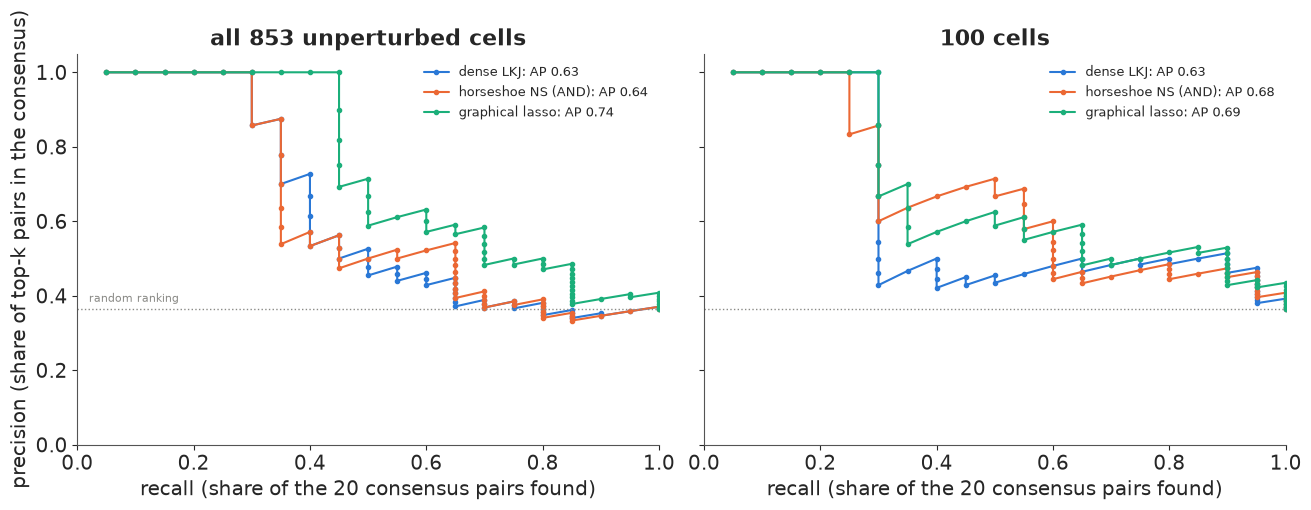

In [16]:
def ranking_score(prob, rho_draws):
    return prob + 1e-6 * np.abs(rho_draws).mean(0)             # probability first, ties by E|rho|


def precision_recall(score):
    hit = truth[np.argsort(-score)]
    tp = np.cumsum(hit)
    k = np.arange(1, len(hit) + 1)
    return tp / k, tp / truth.sum(), (tp / k)[hit].sum() / truth.sum()   # precision, recall, average precision


scores = {
    f"dense LKJ, {N}": ranking_score(prob_dense, pc_dense),
    "dense LKJ, 100": ranking_score(prob_dense_s, pc_dense_s),
    f"horseshoe NS (AND), {N}": ranking_score(fits_ns[f"{N} cells"][0], fits_ns[f"{N} cells"][2]),
    "horseshoe NS (AND), 100": ranking_score(fits_ns["100 cells"][0], fits_ns["100 cells"][2]),
    f"graphical lasso, {N}": glasso[f"{N} cells"][0],
    "graphical lasso, 100": glasso["100 cells"][0],
}
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharey=True)
style = {"dense": BLUE, "horseshoe": ORANGE, "graphical": AQUA}
for name, score in scores.items():
    prec, rec, ap = precision_recall(score)
    ax = axes[0] if name.endswith(str(N)) else axes[1]
    ax.plot(rec, prec, marker="o", ms=3, color=style[name.split()[0]], label=f"{name.rsplit(',', 1)[0]}: AP {ap:.2f}")
for ax, title in zip(axes, [f"all {N} unperturbed cells", "100 cells"]):
    ax.axhline(truth.mean(), color=GREY, ls=":", lw=1)
    ax.set(xlabel="recall (share of the 20 consensus pairs found)", title=title, xlim=(0, 1), ylim=(0, 1.05))
    ax.legend(fontsize=9, loc="upper right")
axes[0].set_ylabel("precision (share of top-k pairs in the consensus)")
axes[0].annotate("random ranking", (0.02, truth.mean() + 0.02), fontsize=8, color=GREY);

With all 853 cells every method's first six pairs are consensus edges, and the graphical
lasso goes on to nine in a row, winning on average precision (0.74 against 0.63 and 0.64) - for
an instructive reason. Its list contains Erk-PKA (sixth) and PLC-PIP2 (ninth), consensus edges
whose *partial* correlations are near zero but whose *marginal* correlations are not (0.36 and
0.08). The lasso's first edges follow the marginal covariance (at a given
$\lambda$ its graph has the same connected components as $|S_{jk}| > \lambda$; Mazumder & Hastie
2012), so a heavily penalised lasso ranks partly by marginal association, which this benchmark
happens to reward. The Bayesian models rank p38-Jnk seventh because its partial correlation
really is 0.14 - a "false positive" only relative to the literature. With 100 cells the order
flips slightly (horseshoe 0.68, lasso 0.69, dense 0.63), but that is one subsample.

One subsample of 100 cells could be lucky or unlucky. Repeating the small experiment on eight
disjoint sets of 100 cells costs a minute and says how much of the difference is real. Two
yardsticks: average precision against the consensus, and against the **full-data graph**
(the pairs with $P(|\rho| > 0.1) > 0.5$ under the dense model with all 853 cells) - what an
experiment 8.5 times bigger would have concluded.

In [17]:
full_graph = prob_dense > 0.5
print(f"full-data graph: {full_graph.sum()} edges, {(full_graph & truth).sum()} in the consensus")


def average_precision(score, target):
    hit = target[np.argsort(-score)]
    return (np.cumsum(hit) / np.arange(1, len(hit) + 1))[hit].sum() / target.sum()


rows = []
blocks = rng.permutation(N)[: 8 * N_SMALL].reshape(8, N_SMALL)
t0 = time.time()
for r, rows_r in enumerate(blocks):
    Zr = (X[rows_r] - X[rows_r].mean(0)) / X[rows_r].std(0)
    with dense_model(Zr):
        idr = pm.sample(random_seed=RANDOM_SEED + r, progressbar=False)
    pc_r = draws(idr, "pcor")[:, IU[0], IU[1]]
    s_dense = ranking_score((np.abs(pc_r) > DELTA).mean(0), pc_r)
    div_d = int(idr.sample_stats["diverging"].sum())
    with ns_model(Zr):
        idr = pm.sample(target_accept=0.99, random_seed=RANDOM_SEED + r, progressbar=False)
    p_and, p_or, rho_r = ns_edge_probs(draws(idr, "B"))
    div_ns = int(idr.sample_stats["diverging"].sum())
    del idr
    entry_r, _, ebic_graph = glasso_path(Zr)
    p_rho = (np.abs(rho_r) > DELTA).mean(0)
    for method, score, graph in [("dense LKJ", s_dense, s_dense > 0.5),
                                 ("horseshoe NS (AND)", ranking_score(p_and, rho_r), p_and > 0.5),
                                 ("horseshoe NS (OR)", ranking_score(p_or, rho_r), p_or > 0.5),
                                 ("horseshoe NS (rho)", ranking_score(p_rho, rho_r), p_rho > 0.5),
                                 ("graphical lasso", entry_r, ebic_graph)]:
        rows.append({"subsample": r, "method": method, "AP vs consensus": average_precision(score, truth),
                     "AP vs full-data graph": average_precision(score, full_graph),
                     "edges": graph.sum(), "in full-data graph": (graph & full_graph).sum(),
                     "in consensus": (graph & truth).sum()})
    print(f"subsample {r}: divergences dense {div_d}, NS {div_ns}")
print(f"8 subsamples: {time.time() - t0:.0f} s")
reps = pd.DataFrame(rows)
reps.groupby("method")[["AP vs consensus", "AP vs full-data graph"]].agg(["mean", "std"]).round(2)

full-data graph: 8 edges, 7 in the consensus


subsample 0: divergences dense 0, NS 0


subsample 1: divergences dense 0, NS 0


subsample 2: divergences dense 0, NS 1


subsample 3: divergences dense 0, NS 0


subsample 4: divergences dense 0, NS 0


subsample 5: divergences dense 0, NS 0


subsample 6: divergences dense 0, NS 0


subsample 7: divergences dense 0, NS 0
8 subsamples: 43 s


AP vs consensus       AP vs full-data graph      
                              mean   std                  mean   std
method                                                              
dense LKJ                     0.66  0.03                  0.86  0.08
graphical lasso               0.69  0.08                  0.85  0.07
horseshoe NS (AND)            0.68  0.07                  0.88  0.06
horseshoe NS (OR)             0.69  0.07                  0.89  0.05
horseshoe NS (rho)            0.69  0.07                  0.88  0.05

As **rankings**, the methods are indistinguishable: every average precision is within about
one standard deviation of every other (0.66-0.69 against the consensus, 0.85-0.89 against the
full-data graph). If all you want is a list of pairs sorted by strength, the dense model and
the lasso are as good as anything here.

Rankings are what a precision-recall curve scores, but a scientist ends up with **one graph**.
Take each method's decision - edge if the posterior probability exceeds 0.5 (for the lasso:
the EBIC graph) - and count, averaged over the eight subsamples:

In [18]:
reps.groupby("method")[["edges", "in full-data graph", "in consensus"]].mean().round(1)

,edges,in full-data graph,in consensus
method,,,
dense LKJ,23.1,7.4,11.8
graphical lasso,5.6,4.9,5.5
horseshoe NS (AND),4.8,4.6,4.6
horseshoe NS (OR),7.5,6.2,6.8
horseshoe NS (rho),5.5,5.1,5.4


This is where the priors differ. The dense model, taken at its word, declares 23 edges from
100 cells. It catches 7.4 of the 8 full-data edges, but the other ~16 are mostly noise: they
hit the consensus at roughly the rate of randomly chosen pairs (one in three). The sparse
methods declare 5-8 edges, and nearly all of them are edges that 853 cells confirm: the
horseshoe with the AND rule is right 4.6 times out of 4.8, the OR rule finds more (6.2 of the
8) for about one extra false edge, and the symmetric $\rho$ rule and the EBIC lasso sit in
between. **Shrinkage does not rank better; it decides better** - the posterior of the
sparse model puts its mass on graphs that a larger experiment would confirm.

### The graphs

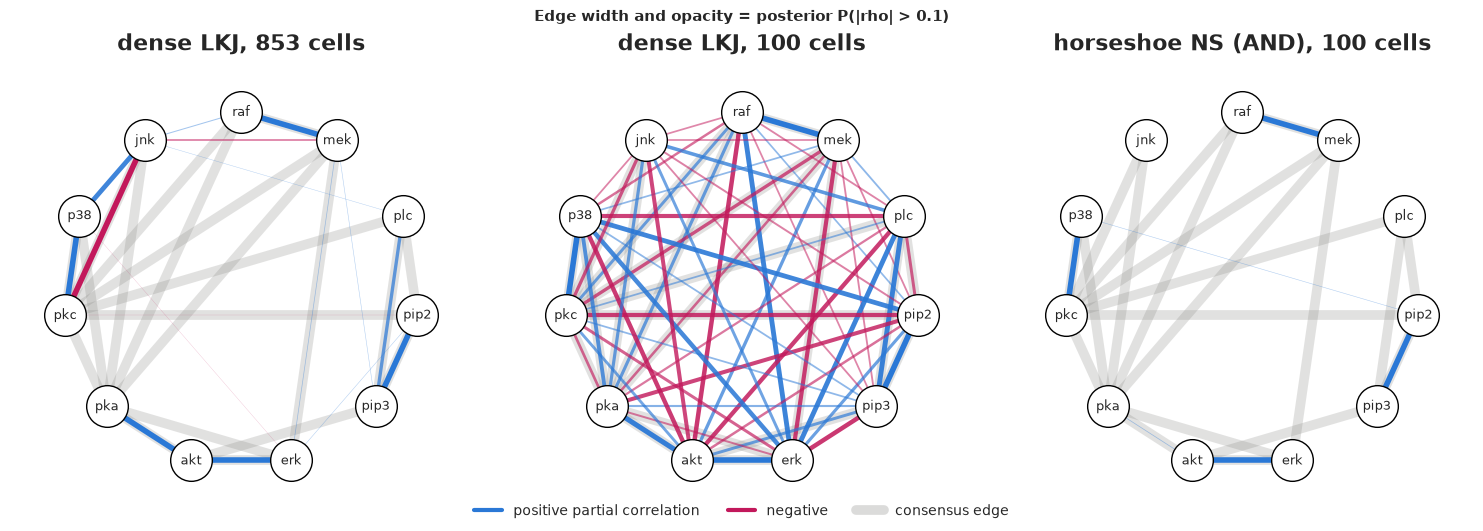

In [19]:
def draw_graph(ax, weight, sign, title, show_truth=True):
    angle = np.pi / 2 - 2 * np.pi * np.arange(P) / P
    xy = np.c_[np.cos(angle), np.sin(angle)]
    if show_truth:
        for j, k in zip(*IU):
            if TRUE[j, k]:
                ax.plot(*xy[[j, k]].T, color=GREY, lw=7, alpha=0.25, solid_capstyle="round", zorder=1)
    for w, s, j, k in zip(weight, sign, *IU):
        if w > 0.05:
            ax.plot(*xy[[j, k]].T, color=BLUE if s > 0 else RED, lw=4 * w, alpha=0.3 + 0.7 * w, zorder=2)
    ax.scatter(*xy.T, s=900, color="white", edgecolor="k", zorder=3)
    for j in range(P):
        ax.text(*xy[j], V[j], ha="center", va="center", fontsize=9, zorder=4)
    ax.set(xlim=(-1.3, 1.3), ylim=(-1.3, 1.3), aspect="equal", title=title)
    ax.axis("off")


fig, axes = plt.subplots(1, 3, figsize=(15, 5.2))
draw_graph(axes[0], prob_dense, np.median(pc_dense, 0), f"dense LKJ, {N} cells")
draw_graph(axes[1], prob_dense_s, np.median(pc_dense_s, 0), "dense LKJ, 100 cells")
draw_graph(axes[2], fits_ns["100 cells"][0], np.median(fits_ns["100 cells"][2], 0), "horseshoe NS (AND), 100 cells")
fig.legend([Line2D([], [], color=BLUE, lw=3), Line2D([], [], color=RED, lw=3),
            Line2D([], [], color=GREY, lw=7, alpha=0.3)],
           ["positive partial correlation", "negative", "consensus edge"], loc="lower center", ncol=3, fontsize=10)
fig.suptitle("Edge width and opacity = posterior P(|rho| > 0.1)", fontsize=11);

The three panels are the story of sections 3-5 in one picture. With 853 cells the dense model
draws eight clear edges and a few faint ones. With 100 cells the same model draws a hairball:
the strongest pairs still stand out, but dozens of others are drawn at half strength. The
horseshoe on the same 100 cells draws four clean edges - Raf-Mek, Erk-Akt, PKC-p38,
PIP2-PIP3 - and almost nothing else. Notice also what *no* panel has: most of the grey
consensus spokes from PKA and PKC. Those two kinases are hubs of the literature network, and
they are exactly the molecules the experimenters manipulated in the other conditions. In
unperturbed cells their influence shows up weakly or not at all.

## 8 · What the graph cannot say

**Pooling the interventions.** Why not use all 7466 cells? Because each condition is a
different system. An inhibitor that switches off Mek removes the dependence between Mek and
Erk in those cells *and* moves their means; mixing conditions creates correlations between any
two molecules whose levels shift together across conditions. A quick look with the plug-in
partial correlations, before and after removing each condition's means:

In [20]:
def plugin_pcor(Xdata):
    Om = np.linalg.inv(np.cov(Xdata.T))
    return (-Om / np.sqrt(np.outer(np.diag(Om), np.diag(Om))))[IU]


X_all = sachs[V].to_numpy()
group = sachs.groupby(list(conditions)).ngroup().to_numpy()
X_within = X_all - pd.DataFrame(X_all).groupby(group).transform("mean").to_numpy()
comparison = pd.DataFrame({"unperturbed (853)": PC[IU], "all pooled (7466)": plugin_pcor(X_all),
                           "pooled, condition means removed": plugin_pcor(X_within), "consensus": truth}, index=PAIRS)
comparison["max change"] = (comparison.iloc[:, 1:3].sub(comparison.iloc[:, 0], axis=0)).abs().max(axis=1)
comparison.sort_values("max change", ascending=False).head(10).round(2)

,unperturbed (853),all pooled (7466),"pooled, condition means removed",consensus,max change
pkc-jnk,-0.29,0.25,0.13,True,0.54
mek-akt,-0.04,0.47,-0.03,False,0.51
mek-erk,0.06,-0.43,0.03,True,0.49
plc-pip2,0.03,0.47,0.21,True,0.44
plc-pka,-0.03,-0.32,-0.00,False,0.29
mek-jnk,-0.09,0.18,-0.00,False,0.27
raf-jnk,0.07,-0.18,-0.00,False,0.25
akt-pka,0.25,0.01,0.29,True,0.24
erk-pka,-0.03,0.17,-0.01,True,0.20
pka-p38,0.02,-0.18,0.00,True,0.20


Pooling rewrites the graph. PKC-Jnk flips from -0.29 to +0.25; Mek-Akt goes from nothing to
0.47; Mek-Erk from 0.06 to -0.43. Removing each condition's means undoes much of it (Mek-Akt
back to -0.03, Mek-Jnk and Raf-Jnk back to 0), but not all: PKC-Jnk (+0.13), PLC-PIP2
(+0.21) and Akt-PKA (+0.29) still differ from the unperturbed cells, because an inhibitor
changes the *dependence* between molecules, not only their levels. The pooled cells are a
mixture of nine different Gaussian graphical models, and no single $\Omega$ describes them.
Used properly, those interventions are the most valuable part of the data - which is the
subject of E20.

**Direction.** Even a perfect estimate of the skeleton is silent about arrows. The graph says
Raf and Mek are directly linked; it cannot distinguish Raf $\to$ Mek from Mek $\to$ Raf, and for
three variables $A - B - C$ with no $A - C$ edge the three structures $A \to B \to C$,
$A \leftarrow B \leftarrow C$ and $A \leftarrow B \to C$ imply exactly the same precision
matrix. Only the *collider* $A \to B \leftarrow C$ is different - and there a GGM does
something surprising: conditioning on $B$ makes $A$ and $C$ dependent, so the GGM adds an
$A - C$ edge that is not a causal connection at all ("moralisation"). A few pieces of
information break the symmetry: colliders in observational data, and interventions - the
very conditions we set aside here. That is where **E20** picks up, with the same data and
directed acyclic graphs.

There is also a hint of direction hiding in this notebook. A *Cholesky* parametrisation
$\Omega = (I - B)^\top D^{-1} (I - B)$ with $B$ strictly lower triangular is always positive
definite, so a horseshoe on $B$ is a legitimate sparse-precision prior for NUTS. But it
only works for a fixed **ordering** of the variables, and $B$ is then the coefficient
matrix of a linear DAG in that order: a sparse $B$ gives a precision matrix with extra
"fill-in" edges, and the answer changes when the order does. Choosing the order is the
causal-discovery problem in disguise.

## 9 · Summary

| Question | Answer here |
|---|---|
| What is an edge? | a non-zero partial correlation = a non-zero entry of $\Omega = \Sigma^{-1}$; operationally $P(|\rho_{jk}| > \delta)$ with a stated $\delta$ |
| Dense model? | `pm.LKJCholeskyCov` + a triangular solve for $\Omega$; fast and clean, but LKJ is a *dense-graph* prior (83% per edge here) |
| Sparse model? | NOT a horseshoe on $\Omega$ (only 1.4% of its prior is positive definite; 281 divergences). Node-wise horseshoe regressions work (0-2 divergences) |
| AND / OR? | disagreements come mostly from coefficient *scaling*, not evidence; a symmetric $\hat\rho$ from both regressions avoids it |
| Does shrinkage help? | with 853 cells, no. With 100 cells not for ranking, but its decided graph has ~5 edges, nearly all confirmed, vs 23 for the dense model |
| Against the consensus? | 6-9 of the 20 literature edges are recovered from unperturbed cells, whatever the method; the graphical lasso scores higher partly by following marginal correlation |
| What is missing? | direction, and the interventions that could reveal it (E20) |

## Try it yourself

1. **Robust edges.** The PPC showed skewed, heavy-tailed marginals. Replace the Gaussian
   likelihood of the neighbourhood regressions with a Student-t (one $\nu$ per node) and see
   which edges survive. Does the p38 - Jnk edge that the consensus lacks go away?
2. **The Cholesky parametrisation.** Build $\Omega = (I - B)^\top D^{-1}(I - B)$ with a horseshoe on
   the strictly lower-triangular $B$, fit it to the 100 cells in two orderings (the order in
   `V` and its reverse) and compare the implied partial correlations and edge probabilities.
   How much of the graph depends on the ordering?
3. **The threshold.** Recompute the dense model's precision-recall curve for
   $\delta = 0.05, 0.1, 0.2$, and try the shrinkage-factor summary $1 - \kappa_{jk}$ (Carvalho,
   Polson & Scott 2010) for the horseshoe instead of a threshold. Which conclusions depend on
   $\delta$, and which do not?